### 경사하강법 및 손실함수

신경망 학습이란? <br>
-> 모델이 내놓은 예측값 $\hat{y}$과 정답 $y$의 차이를 숫자 하나로 표현하고, 이 숫자를 작게 만드는 과정

목표: $L(w) = (y - f(w))^2$ 이 최소가 되는 $w$(가중치)를 찾는 것

#### 1. 왜 미분을 할까?
미분 = 현 위치의 기울기(한 점에 대한 순간 변화율)

$\frac{dL}{dw}$ = $w$를 늘렸을 때, L은 얼마나, 어느 방향으로 이동하는가?
- $\frac{dL}{dw}$ < 0 : $L$을 줄이려면 $w$도 줄어야 함
- $\frac{dL}{dw}$ > 0 : $L$을 줄이려면 $w$를 늘려야 함

즉, 미분값의 부호가 어느 방향으로 가야할지, 크기가 얼마나 가파른지 알려줌 -> 경사하강법의 업데이트 식으로 이뤄짐
$$w_{new} = w_{old} - \eta \cdot \frac{dL}{dw}$$

In [6]:
import numpy as np
from sklearn.datasets import load_diabetes

# 1. 데이터 로드
diabetes = load_diabetes()

x_raw = diabetes.data[:, 2]
y = diabetes.target

x = x_raw * 100

print(f"데이터 개수: {len(x)}")
print(f"x(BMI 스케일) 범위: {x.min():.2f} ~ {x.max():.2f}")
print(f"y(질병 진행도) 범위: {y.min():.2f} ~ {y.max():.2f}")

데이터 개수: 442
x(BMI 스케일) 범위: -9.03 ~ 17.06
y(질병 진행도) 범위: 25.00 ~ 346.00


##### 1. 모델 파라미터 초기화

In [7]:
w = 0.0
b = 0.0
lr = 0.0001
epochs = 2000    

##### 2. 경사하강법 루프

In [8]:
loss_history = []

for epoch in range(epochs) :
    y_pred = w* x + b
    error = y - y_pred
    loss = np.mean(error ** 2)      # MSE
    loss_history.append(loss)
    
    dL_dw = -(2/len(x)) * np.sum(x * error)
    dL_db = -(2/len(x)) * np.sum(error)

    w = w - lr * dL_dw
    b = b - lr * dL_db

    if epoch % 400 == 0:
        print(f"epoch {epoch:4d} | loss={loss:10.2f} | w={w:.4f} | b={b:.4f}")

print(f"\n최종: w={w:.4f}, b={b:.4f}")
print(f"해석: BMI가 (100배 스케일 기준) 1 증가할 때 질병 진행도가 {w:.4f}만큼 변함")

epoch    0 | loss=  29074.48 | w=0.0430 | b=0.0304
epoch  400 | loss=  23666.84 | w=7.9539 | b=11.7258
epoch  800 | loss=  20697.78 | w=9.2433 | b=22.5219
epoch 1200 | loss=  18211.30 | w=9.4534 | b=32.4879
epoch 1600 | loss=  16093.65 | w=9.4877 | b=41.6875

최종: w=9.4933, b=50.1594
해석: BMI가 (100배 스케일 기준) 1 증가할 때 질병 진행도가 9.4933만큼 변함


### 신경망 기초 + 임베딩 & 내적의 의미

$\hat{y} - w \cdot x$을 두 가지로 확장
- 입력이 숫자 하나가 아닌 벡터일 때
- 그 벡터가 "임베딩"이라는 것 - 임베딩 간 유사도를 재는 도구가 "내적"

#### 1. 내적 사용 의도와 본질
<내적의 정의> <br>
두 벡터 $\alpha$($\alpha_1, \alpha_2, \alpha_3, ..., \alpha_n$)과 $\beta$($\beta_1, \beta_2, \beta_3, ..., \beta_n)의 내적은: <br>
$$ \alpha \cdot \beta = \sum_{i=1}^n {a_i}{b_i} = a_1b_1 + a_2b_2 + ... a_nb_n$$

- 의도: $a \cdot b = \lvert a \rvert \, \lvert b \rvert \cos(\theta)$
    - 두 벡터가 같은 방향을 보고 있으면 ($\theta = 0^\circ$) -> $cos \theta = 1$
    - 두 벡터가 수직 ($\theta = 90^\circ$) -> $cos \theta = 0$
    - 두 벡터가 수직 ($\theta = 180^\circ$) -> $cos \theta = -1$

**즉, 내적의 본질은 "두 벡터가 얼마나 같은 방향을 향하고 있는가"**

#### 2. 임베딩이란?
임베딩: 사람이 이해하는 대상을 숫자로 이루어진 벡터로 변환하는 것 <br>
-> 벡터의 각 숫자(차원)는 처음에는 무작위로 시작. 학습(경사하강법)을 거치며 "의미가 비슷한 단어는 비슷한 벡터를 갖도록" 조정

#### 3. 선형 모델에서 신경망으로의 확장
$\hat{y} = w \cdot x$ 입력이 벡터 $x$, 가중치 또한 벡터 $w$라면 <br>
$\hat{y} = w \cdot x + b = w_1x_1 + w_2x_2 + ... + w_nb_n + b$ <br>
$\hat{y} = \sigma(w \cdot x + b)$ -> $\sigma$(시그모이드)를 씌우면 그 숫자를 0~1 사이 확률처럼 해석 가능

In [ ]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X_all = iris.data
y_all = iris.target

# 1. "내적 = 유사도" 확인
# -> 같은 종끼리의 내적이 다른 종끼리보다 큰지 확인

def cosine_sim(a, b):
    # a·b = |a||b|cosθ  →  cosθ = (a·b) / (|a||b|)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

setosa_1, setosa_2 = X_all[0], X_all[1]
versicolor_1 = X_all[50]

print("같은 종(setosa-setosa) 유사도:", round(cosine_sim(setosa_1, setosa_2), 4))
print("다른 종(setosa-versicolor) 유사도:", round(cosine_sim(setosa_1, versicolor_1), 4))

# 2. 다차원 뉴런: ŷ = σ(w·x + b)를 경사하강법으로 학습
#   setosa(0) vs versicolor(1) 이진분류 (virginica는 제외)

mask = y_all != 2
X = X_all[mask]
y = y_all[mask].astype(float)

def sigmoid(z) :
    return 1 / (1 + np.exp(-z))

w = np.zeros(X.shape[1])
b = 0.0
lr = 0.1
epochs = 500

for epoch in range(epochs) :
    # ── ŷ = σ(w·x + b) : 100개 샘플에 대해 한 번에 계산 ──
    z = X @ w + b                    # (100,4)@(4,) = (100,) → 100개 샘플의 내적 결과
    y_pred = sigmoid(z)              # 각 내적값을 0~1 확률로 변환

    error = y - y_pred               # (100,)
    loss = np.mean(error ** 2)       # MSE (Day1과 동일한 손실 형태)

    # 기울기: Day1의 dL/dw 공식이 그대로 확장됨 (x가 벡터이므로 결과도 벡터)
    # dL/dw = -(2/n) * X^T @ (error * σ'(z))  ← σ'(z)=σ(z)(1-σ(z))
    d_sigmoid = y_pred * (1 - y_pred)
    dL_dw = -(2/len(X)) * (X.T @ (error * d_sigmoid))   # (4,) — 4개 가중치 각각의 기울기
    dL_db = -(2/len(X)) * np.sum(error * d_sigmoid)

    w = w - lr * dL_dw
    b = b - lr * dL_db

    if epoch % 100 == 0:
        acc = np.mean((y_pred > 0.5) == y)
        print(f"epoch {epoch:3d} | loss={loss:.4f} | acc={acc:.2f}")

print(f"\n최종 학습된 w: {np.round(w, 3)}")
print(f"특성 이름:      {iris.feature_names}")

같은 종(setosa-setosa) 유사도: 0.9986
다른 종(setosa-versicolor) 유사도: 0.9284
epoch   0 | loss=0.2500 | acc=0.50
epoch 100 | loss=0.0252 | acc=1.00
epoch 200 | loss=0.0124 | acc=1.00
epoch 300 | loss=0.0082 | acc=1.00
epoch 400 | loss=0.0061 | acc=1.00

최종 학습된 w: [-0.289 -1.064  1.623  0.706]
특성 이름:      ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### 활성화 함수 & MLP & 역전파

#### 1. 맨 앞쪽 층의 가중치는 어떻게 업데이트할까?
실제 신경망의 구조: 입력 -> Layer 1 -> Layer 2 -> ... -> Layer n -> 출력
    - 각 층마다 가중치는 따로 존재
    - 출력층에서 멀리 떨어진 맨 앞쪽 층(Layer 1)의 가중치는 어떻게 업데이트할까? <br>
    -> $\frac{dL}{dw}$ 하나로는 부족. 여기서는 Chain Rule이 "층의 개수만큼 연쇄적으로 적용" = 역전파(Backpropagation)

#### 2. 비선형 활성화 함수의 필요성 증명
ex) 두 개의 선형 층을 쌓았다고 가정 (활성화 함수 X)
$h = w_1 x, \hat{y} = w_2 h = w_2(w_1 x) = (w_2 w_1)x$ -> $w_2 w_1$은 하나의 행렬. $w_3 = w_2 w_1$으로 치환 시:
$\hat{y} = w_3 x$

결론: 선형 층을 무한히 쌓더라도 결국 $\hat{y} = w_n x$ 형태의 단일 선형 변환이므로 층을 쌓는 의미가 없음 -> 각 층 사이에 비선형 함수 $\sigma$를 삽입해야 함. <br>
$h = \sigma(w_1 x), \hat{y} = w_2 h = w_2 \sigma(w_1 x)$

#### 3. 활성화 함수: Sigmoid, ReLU
##### (1) Sigmoid
$\sigma(z) = \frac{1}{1+e^{-x}}$ 출력을 항상 (0, 1) 사이로 압축 <br>
미분 시: $\sigma'(z) = \sigma(z)(1-\sigma(z))$

##### (2) ReLU
$ReLU(z) = max(0, z)$ <br>
$\quad z > 0$이면 그대로 통과, z $\leq 0$이면 0 -> 미분값이 0 또는 1, 1인 구간에서 기울기가 더 작아지지 않고 그대로 전달됨.

#### 4. 역전파(Backpropagation)
- 2층 신경망 예시
- 구조: 입력 $x$ -> (가중치 $w_1$) -> 은닉층 $h$ -> (가중치 $w_2$) -> 출력 $\hat{y}$ -> 손실 $L$
$$ h = \sigma(w_1 x), \hat{y} = w_2 h, L = (y - \hat{y})^2$$

$w_1$에 대한 $\frac{\partial L}{\partial {w_1}}$은 어떻게 구할까?
$w_1$이 $L$에 영향을 주는 경로는 다음과 같이 연쇄적: $w_1$ -> $h$ -> $\hat{y}$ -> $L$
- Chain Rule을 이어 붙이면 :
$ \frac {\partial L}{\partial w_1} = \frac {\partial L}{\partial{\hat{y}}} \cdot \frac {\partial {\hat{y}}}{\partial h} \cdot \frac {\partial h}{\partial w_1}$
- 각 항을 따로 계산 시:
    - $\frac {\partial L}{\partial{\hat{y}}} = -2(y - \hat{y})$
    - $\frac {\partial {\hat{y}}}{\partial h} = w_2$
    - $\frac {\partial h}{\partial w_1} = \sigma'(w_1 x) \cdot x$

In [13]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X_all, y_all = iris.data, iris.target

mask = y_all != 0
X = X_all[mask]
y = (y_all[mask] == 2).astype(float)

np.random.seed(0)
n_in, n_hidden = 4, 4
W1 = np.random.randn(n_in, n_hidden) * 0.5   # 입력(4) → 은닉(4)
b1 = np.zeros(n_hidden)
W2 = np.random.randn(n_hidden, 1) * 0.5      # 은닉(4) → 출력(1)
b2 = 0.0

def relu(z):        return np.maximum(0, z)              # 비선형성 담당
def relu_deriv(z):  return (z > 0).astype(float)          # z<=0이면 0 → Dying ReLU 지점
def sigmoid(z):      return 1 / (1 + np.exp(-z))

lr = 0.05
for epoch in range(3000):
    # 순전파: 이론의 W₂(W₁x) 구조에 비선형(relu)을 끼워 넣음
    z1 = X @ W1 + b1
    h  = relu(z1)                 # 여기가 비선형 → 층을 쌓는 의미가 생기는 지점
    z2 = h @ W2 + b2
    y_pred = sigmoid(z2).flatten()

    error = y - y_pred
    loss = np.mean(error**2)
    
    # ── 역전파: 체인룰을 손실→출력→은닉→입력 방향으로 역순 적용 ──
    # ∂L/∂ŷ
    dL_dypred = -2*error/len(X)
    # ∂ŷ/∂z2 (sigmoid 미분)
    dypred_dz2 = y_pred*(1-y_pred)
    delta2 = (dL_dypred * dypred_dz2).reshape(-1,1)       # ∂L/∂z2
    dL_dW2 = h.T @ delta2                                  # ∂L/∂z2 · ∂z2/∂W2
    dL_db2 = np.sum(delta2)

    # ∂z2/∂h = W2 이므로 delta2 @ W2.T로 은닉층까지 기울기 전파
    dh = delta2 @ W2.T
    # ∂h/∂z1 = relu_deriv(z1)  ← Dying ReLU가 실제로 발생할 수 있는 지점
    dz1 = dh * relu_deriv(z1)
    dL_dW1 = X.T @ dz1                                     # ∂z1/∂W1
    dL_db1 = np.sum(dz1, axis=0)

    W2 -= lr*dL_dW2; b2 -= lr*dL_db2
    W1 -= lr*dL_dW1; b1 -= lr*dL_db1

    if epoch % 500 == 0:
        acc = np.mean((y_pred>0.5)==y)
        print(f"epoch {epoch:4d} | loss={loss:.4f} | acc={acc:.3f}")

epoch    0 | loss=0.4318 | acc=0.500
epoch  500 | loss=0.1278 | acc=0.820
epoch 1000 | loss=0.0455 | acc=0.970
epoch 1500 | loss=0.0360 | acc=0.970
epoch 2000 | loss=0.0321 | acc=0.970
epoch 2500 | loss=0.0300 | acc=0.970


PyTorch 예시

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.datasets import load_iris

# 데이터 정의
iris = load_iris()
X_all, y_all = iris.data, iris.target
mask = y_all != 0
X = torch.tensor(X_all[mask], dtype=torch.float32)                       
y = torch.tensor((y_all[mask] == 2).astype(np.float32)).reshape(-1, 1)   

torch.manual_seed(0)

# 모델 정의
class MLP(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.fc1 = nn.Linear(4, 4)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x) :
        h = self.relu(self.fc1(x))
        return self.sigmoid(self.fc2(h))
    
model = MLP()
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

for epoch in range(3000) :
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    
    optimizer.zero_grad()
    loss.backward() # 내부 연산은 delta2 = ... ; dh = delta2 @ W2.T ; dz1 = dh * relu_deriv(z1) ; dL_dW1 = X.T @ dz1와 동일한 연산
    optimizer.step()
    
    if epoch % 500 == 0:
        acc = ((y_pred > 0.5) == y).float().mean()
        print(f"epoch {epoch:4d} | loss={loss.item():.4f} | acc={acc:.3f}")

epoch    0 | loss=0.2429 | acc=0.720
epoch  500 | loss=0.1084 | acc=0.950
epoch 1000 | loss=0.0576 | acc=0.970
epoch 1500 | loss=0.0429 | acc=0.970
epoch 2000 | loss=0.0366 | acc=0.970
epoch 2500 | loss=0.0332 | acc=0.970


### Softmax & Cross-Entropy & MLP의 한계
: 분류 문제에서는 회귀와 다른 출력층 함수(`Softmax`)와 손실 함수(`Cross-Entropy`)가 필요.

#### 1. Softmax
**[문제 상황]** <br>
세 가지 클래스 중 하나를 분류 <br>
-> 신경망의 출력층은 숫자 3개를 출력 ex) $z$ = [$z_1, z_2, z_3$] = [2.0, 1.0, 0.1]
- 수식
$$ Softmax(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}} $$

**Q1. 왜 정규화하지 않고 지수함수를 쓸까?**
- 음수를 처리하기 위해
- 차이를 **증폭**시켜 가장 큰 값을 부각시키기 위해


#### 2. Cross-Entropy Loss - "확률 분포 사이의 차이"를 재는 손실함수
정답이 One-Hot Vector로 주어진다고 가정. 예를 들어 정답이 "강아지"이면: <br>
$y$ = [1, 0, 0] (강아지 = 1, 고양이 = 0, 새 = 0) <br>
모델이 예측한 확률(Softmax 결과)이 $\hat{y}$ = [0.659, 0.242, 0.099]라면, <br>
$$ Cross Entropy Loss : L = - \sum_i y_i \log{\hat{y_i}} $$
정답이 One-Hot이므로 $y_i = 0$인 항은 전부 사라지고 정답 클래스에 해당하는 항만 남음. <br>
$ L = -\log(\hat{y} 정답클래스) = -\log(0.659) \approx 0.417 $

**Q2. 왜 로그를 쓸까?**
- "정답에 확신이 없을수록 벌점이 커야 한다"는 비대칭적 차별
    - 정답을 확신($\hat{y} = 1.0$) -> $-\log(1.0) = 0$ -> 손실 X
- 확률의 곱셈을 덧셈으로 바꿔주는 수학적 편의성
    - 확률은 0~1 사이이므로 여러 개를 곱하면 값이 기하급수적으로 작아져 극소수가 됨
- 매끄럽게 미분 가능하면서도 우리가 원하는 비대칭적 페널티 구조를 만들어줌 (회귀의 제곱과 유사한 역할)

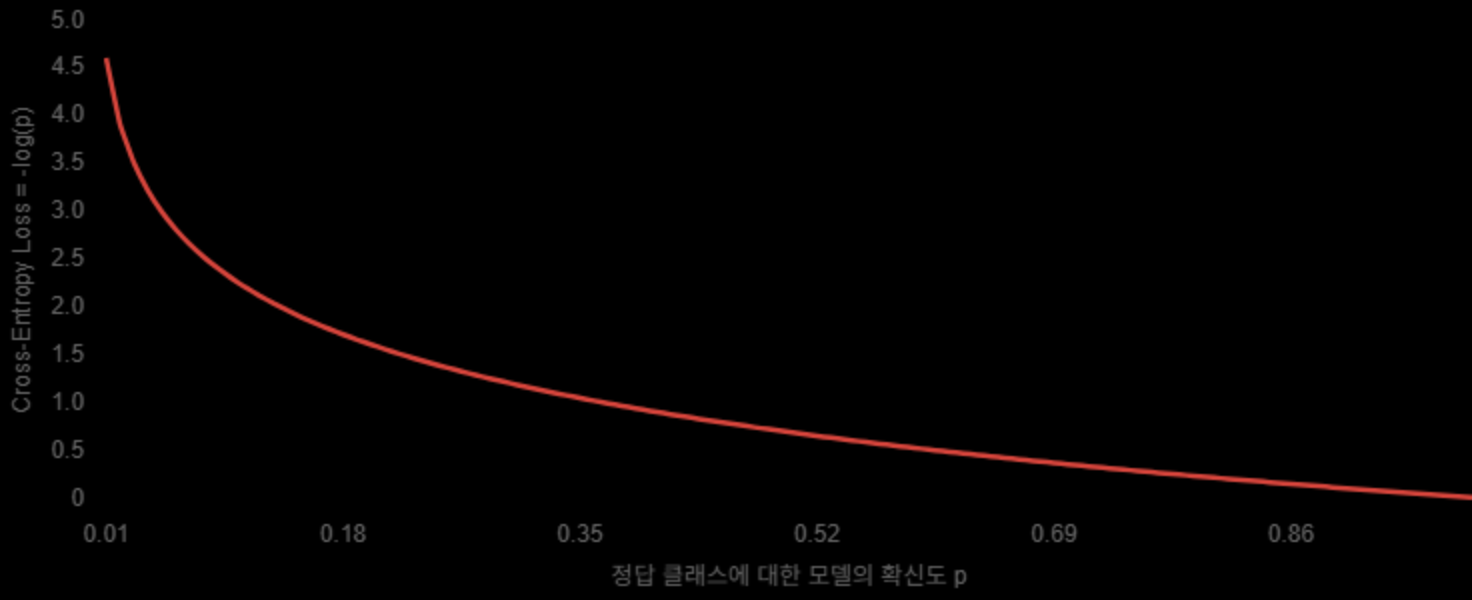
- $p=1$ 근처에서는 곡선이 거의 평평하지만, $p=0$에 가까워질수록 수직으로 솟구치는 것을 확인할 수 있음

#### 3. MLP의 한계 - 왜 문장(시퀀스)에서 사용하지 못할까?
- 1. 입력 크기가 고정되어야 함.
    - MLP는 입력 벡터의 차원이 고정되어 있어야 함 -> 가중치 행렬의 크기가 미리 정해지므로
    - 길이가 가변적인 입력을 고정 크기 모델에 넣을 방법 X
- 2. 순서 정보를 모름
    - 억지로 모든 단어의 임베딩을 이어붙여 고정 크기로 만들더라도 MLP 내부 연산은 각 위치의 숫자를 단순히 곱할 뿐, 순서 개념 X
- 3. 파라미터 수 폭증
    - 문장의 최대 길이를 100단어로 가정 후 MLP를 만들면 입력층 크기 = $(100 \times 임베딩 차원)
    - 문장이 짧으면 Padding으로 채워야 해서 모델이 커지고 비효율적

In [ ]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data                      # (150,4) — 3개 클래스 전체 사용 (Day2,3은 2개만 썼음)
y = iris.target                    # 0=setosa, 1=versicolor, 2=virginica

n_classes = 3
n_samples, n_features = X.shape
Y_onehot = np.eye(n_classes)[y]    # 정수 라벨 → one-hot 변환, 예: 1 → [0,1,0]

np.random.seed(0)
W = np.random.randn(n_features, n_classes) * 0.01   # (4,3) — 4개 특성 → 3개 클래스 점수
b = np.zeros(n_classes)

def softmax(z):
    # 이론: z - max(z) 트릭으로 exp() 오버플로 방지 (결과는 수학적으로 동일)
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

lr = 0.1
for epoch in range(2000):
    z = X @ W + b                      # (150,4)@(4,3) → (150,3) logits
    y_pred = softmax(z)                # 각 행이 3개 클래스에 대한 확률 분포(합=1)

    # ── Cross-Entropy: L = -(1/n)Σ y·log(ŷ) ──
    loss = -np.mean(np.sum(Y_onehot * np.log(y_pred + 1e-9), axis=1))

    # softmax+CE를 함께 쓸 때만 나오는 성질: dL/dz = ŷ - y
    # (softmax의 미분과 log의 미분이 서로 상쇄되어 이렇게 단순해짐)
    dL_dz = (y_pred - Y_onehot) / n_samples
    dL_dW = X.T @ dL_dz
    dL_db = np.sum(dL_dz, axis=0)

    W -= lr*dL_dW
    b -= lr*dL_db

    if epoch % 400 == 0:
        acc = np.mean(np.argmax(y_pred, axis=1) == y)
        print(f"epoch {epoch:4d} | loss={loss:.4f} | acc={acc:.3f}")

epoch    0 | loss=1.1080 | acc=0.333
epoch  400 | loss=0.1914 | acc=0.980
epoch  800 | loss=0.1388 | acc=0.980
epoch 1200 | loss=0.1165 | acc=0.987
epoch 1600 | loss=0.1039 | acc=0.987
